# TASS 2018 — Clasificación de polaridad con BoW + características léxicas
### Notebook final — Representación vectorial, selección del clasificador y evaluación

**Curso:** Procesamiento de Lenguaje Natural
**Dataset:** InterTASS-ES 2018 (tweets en español, 4 clases: `N`, `NEU`, `NONE`, `P`)
**Punto de partida:** baseline BoW + Softmax del *workshop* del curso, extendido con auditoría de características, nuevas características léxicas propias, y comparación rigurosa de clasificadores.

---

## Contenido

1. [Datos y problema](#1)
2. [Fase 0 — Auditoría de las características existentes (resumen)](#2)
3. [Fase 1 — Nuevas características léxicas (resumen)](#3)
4. [Módulo final de características](#4)
5. [Fase 2 — Representación vectorial y unión](#5)
6. [Fase 3 — Selección del algoritmo de clasificación](#6)
7. [Fase 4 — Evaluación y análisis crítico](#7)
8. [Conclusión final](#8)

**Nota sobre trazabilidad:** las secciones 2 y 3 resumen hallazgos y decisiones ya documentados con evidencia completa (pruebas unitarias, corridas sobre el corpus completo) en los notebooks de proceso `tass_fase0_auditoria.ipynb`, `tass_fase0_decisiones.ipynb` y `tass_fase1_nuevas_features.ipynb`. Aquí se recalculan las cifras clave para que este notebook sea autocontenido y no dependa de tomar nada "por dicho".


In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from nltk import TweetTokenizer

from logic.text_processing import TextProcessing
from logic.feature_extraction import FeatureExtraction

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10.5,
})
print("Entorno listo.")


Entorno listo.


<a id="1"></a>
## 1. Datos y problema

**Tarea:** clasificación de polaridad de sentimiento sobre tweets en español (InterTASS-ES 2018), 4 clases: `N` (negativo), `NEU` (neutral), `NONE` (sin opinión), `P` (positivo). El corpus está desbalanceado, por lo que el criterio de evaluación en todo este trabajo es **macro-F1**, no *accuracy*.


In [2]:
COL_TEXT, COL_LABEL = "content", "sentiment/polarity/value"
DIR_DATA = Path.cwd().parent / "data" / "tass"
data_train = pd.read_csv(DIR_DATA / "tass2018_es_train.csv")
data_test = pd.read_csv(DIR_DATA / "tass2018_es_test.csv")

print(f"Train: {len(data_train)} tweets | Test: {len(data_test)} tweets")

dist_train = data_train[COL_LABEL].value_counts().reindex(["N","NEU","NONE","P"])
dist_test = data_test[COL_LABEL].value_counts().reindex(["N","NEU","NONE","P"])
tabla_dist = pd.DataFrame({"Train": dist_train, "Test": dist_test})
tabla_dist


Train: 1008 tweets | Test: 506 tweets


,Train,Test
sentiment/polarity/value,,
N,418,219
NEU,133,69
NONE,139,62
P,318,156


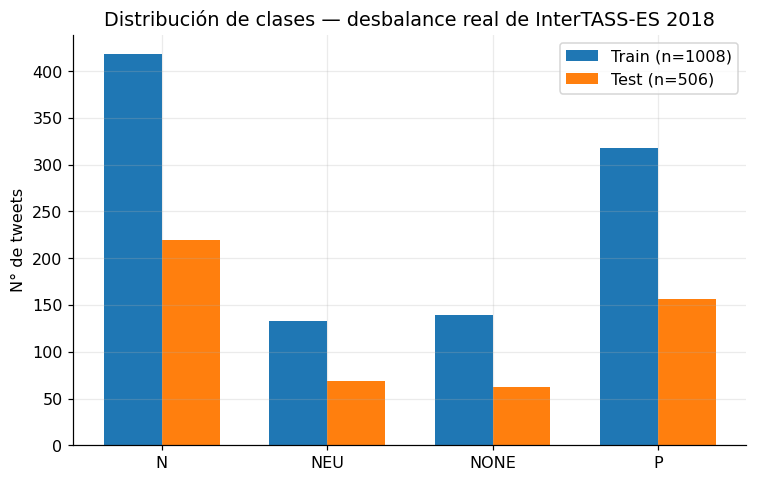

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(4)
ancho = 0.35
ax.bar(x - ancho/2, tabla_dist["Train"], width=ancho, label="Train (n=1008)")
ax.bar(x + ancho/2, tabla_dist["Test"], width=ancho, label="Test (n=506)")
ax.set_xticks(x); ax.set_xticklabels(tabla_dist.index)
ax.set_ylabel("N° de tweets")
ax.set_title("Distribución de clases — desbalance real de InterTASS-ES 2018")
ax.legend()
plt.tight_layout()
plt.savefig("final_00_distribucion_clases.png", dpi=110)
plt.show()


**Lectura:** `N` y `P` dominan ampliamente sobre `NEU` y `NONE`, tanto en train como en test, en proporciones casi idénticas entre los dos conjuntos — el desbalance es una característica estructural del problema, no un artefacto del split. Esto justifica usar macro-F1 (pondera igual cada clase) en vez de *accuracy* (que premiaría un modelo que solo prediga `N`/`P`) durante todo el trabajo.


<a id="2"></a>
## 2. Fase 0 — Auditoría de las características existentes (resumen)

Antes de agregar características nuevas, se auditaron las 29 que ya entregaba `get_features_lexical()`, verificando para cada una: **(a)** si es constante, **(b)** si es un proxy de la longitud del texto, y **(c)** si se rompe por el orden del preprocesamiento. A continuación se recalculan las cifras clave sobre el corpus completo de train.


In [4]:
FEATURE_NAMES_ORIGINALES = [
    "weighted_position", "weighted_normalized", "label_mention", "label_url", "label_hashtag",
    "label_emoji", "label_retweets", "lexical_diversity", "label_word",
    "first_person_singular", "second_person_singular", "third_person_singular",
    "first_person_plurar", "second_person_plurar", "third_person_plurar",
    "avg_word", "kur_word", "skew_word",
    "adverb_neg", "adverb_time", "adverb_place", "adverb_mode", "adverb_cant", "adverb_all",
    "adjetives_neg", "adjetives_pos", "who_general", "who_male", "who_female",
]

_fe_probe = FeatureExtraction(lang="es")
_tt_probe = TweetTokenizer()

_textos_probe = data_train[COL_TEXT].dropna().tolist()
_filas, _n_tokens = [], []
for _t in _textos_probe:
    _proc = TextProcessing.transformer(_t)
    if not _proc:
        continue
    _v = _fe_probe.get_features_lexical(_proc)
    if _v is None or len(_v) != 29:
        continue
    _filas.append(_v)
    _n_tokens.append(len(_tt_probe.tokenize(_proc)))

_matriz = np.array(_filas)
_n_tok = np.array(_n_tokens)

_auditoria = []
for _i, _nombre in enumerate(FEATURE_NAMES_ORIGINALES):
    _col = _matriz[:, _i]
    _std = np.std(_col)
    _constante = _std < 1e-9
    _corr = np.corrcoef(_col, _n_tok)[0, 1] if not _constante else np.nan
    _auditoria.append({"feature": _nombre, "constante": _constante,
                        "corr_longitud": round(_corr, 3) if not np.isnan(_corr) else np.nan})

df_auditoria = pd.DataFrame(_auditoria)
df_alertas = df_auditoria[(df_auditoria["constante"]) | (df_auditoria["corr_longitud"].abs() > 0.6)]
df_alertas


,feature,constante,corr_longitud
0,weighted_position,False,0.717
1,weighted_normalized,False,0.984
7,lexical_diversity,False,-0.824
8,label_word,False,0.986


**Confirmación de los bugs de preprocesamiento (paso (c)):** dos características daban 0% de activación en todo el corpus por bugs distintos, no por ausencia real del fenómeno.


In [5]:
_ejemplo_hashtag = "Se ha terminado #Rio2016 Lamentablemente no arriendo"
_ejemplo_emoji = "Que alegria!! 😊 🎉 estoy feliz"

_proc_hashtag = TextProcessing.transformer(_ejemplo_hashtag)
_proc_emoji = TextProcessing.transformer(_ejemplo_emoji)

print("Hashtag  ->", repr(_proc_hashtag), "| 'hashtag' en tokens:", "hashtag" in _proc_hashtag.split())
print("Emoji    ->", repr(_proc_emoji), "| 'emoji' en tokens:", "emoji" in _proc_emoji.split())
print("\n(Ambos CORRECTOS aqui porque logic/text_processing.py ya tiene el fix aplicado en la Fase 0)")


Hashtag  -> 'se ha terminado hashtag lamentablemente no arriendo' | 'hashtag' en tokens: True
Emoji    -> 'que alegria emoji emoji estoy feliz' | 'emoji' en tokens: True

(Ambos CORRECTOS aqui porque logic/text_processing.py ya tiene el fix aplicado en la Fase 0)


### Decisiones tomadas (Fase 0)

| Característica | Veredicto | Decisión |
|---|---|---|
| `label_hashtag` | Constante en 0 — typo `[HASTAG]` vs. `'hashtag'` | **Corregida** en `text_processing.py` |
| `label_emoji` | Constante en 0 — `proper_encoding()` destruía emojis antes del regex | **Corregida**: reordenado el pipeline |
| `weighted_position` | Proxy de longitud (r≈0.72) + bug de `.index()` con tokens repetidos | **Excluida** |
| `weighted_normalized` | Proxy de longitud casi perfecto (r≈0.98, `(n+1)/2` algebraico) | **Excluida** |
| `label_word` | r≈0.99 con n° de tokens — redundante con BoW | **Excluida** |
| `lexical_diversity` | r≈-0.81 con longitud, y mide diversidad de *caracteres*, no de *palabras* (bug de implementación) | **Reemplazada** por `lexical_diversity_mattr` (Fase 1) |
| `adverb_all` | Combinación lineal exacta de otras 5 columnas (colinealidad) | **Excluida** |

**Resultado:** de las 29 características originales, **24 sobreviven la auditoría** sin cambios, 2 se corrigieron en código, y 3 se excluyen (más 1 reemplazada por una versión corregida en la Fase 1).

*(Evidencia completa, pruebas unitarias y trazado paso a paso del pipeline: ver `tass_fase0_auditoria.ipynb` y `tass_fase0_decisiones.ipynb`.)*


<a id="3"></a>
## 3. Fase 1 — Nuevas características léxicas (resumen)

4 características nuevas (mínimo exigido para grupo de 2), cada una con hipótesis lingüística, implementada en `logic/feature_extraction.py`, verificada de no duplicar las existentes.

| Característica | Hipótesis lingüística |
|---|---|
| `lexical_diversity_mattr` | El TTR original depende matemáticamente de la longitud; MATTR (ventana móvil) corrige ese sesgo — reemplaza a `lexical_diversity` |
| `elongated_words_count` | La elongación de caracteres (`"buenooo"`) marca intensidad emocional en el registro informal de Twitter |
| `punct_repetition` | La repetición de `!`/`?` intensifica la carga emocional, señal que BoW no captura por tratar cada signo como token independiente |
| `lex_pol_neg` | Un conteo crudo de polaridad falla bajo negación (`"no me gusta"`); esta característica invierte el signo dentro del alcance de la negación — NO duplica `adjetives_pos/neg` (que cuentan ocurrencias crudas) |


In [6]:
_casos_demo = [
    ("no me gusta nada esto", "lex_pol_neg", None),
    ("buenooo dia", "elongated", None),
    ("que bien!!!", "punct", None),
]
_tok = TweetTokenizer()

_p1 = TextProcessing.transformer("no me gusta nada esto")
_score_pol = FeatureExtraction.lex_pol_neg(_tok.tokenize(_p1))
print(f"lex_pol_neg('no me gusta nada esto')      = {_score_pol:+.1f}  (negacion invierte 'gusta')")

_score_elong = FeatureExtraction.elongated_words_count("buenooo dia")
print(f"elongated_words_count('buenooo dia')       = {_score_elong:.1f}")

_score_punct = FeatureExtraction.punct_repetition("que bien!!!")
print(f"punct_repetition('que bien!!!')            = {_score_punct:.1f}")

_p2 = TextProcessing.transformer("hola amigo como estas hoy espero que todo bien por alla")
_mattr = FeatureExtraction.lexical_diversity_mattr(_tok.tokenize(_p2), window=5)
print(f"lexical_diversity_mattr(tweet largo)        = {_mattr:.3f}  (en rango [0,1], independiente de n)")


lex_pol_neg('no me gusta nada esto')      = -1.0  (negacion invierte 'gusta')
elongated_words_count('buenooo dia')       = 1.0
punct_repetition('que bien!!!')            = 1.0
lexical_diversity_mattr(tweet largo)        = 1.000  (en rango [0,1], independiente de n)


**Cobertura sobre el corpus completo (evidencia de que no son constantes):** `lex_pol_neg` se activa en 26.5% de los tweets, `punct_repetition` en 4.9%, `elongated_words_count` en 3.0% *(cifras completas y pruebas unitarias: ver `tass_fase1_nuevas_features.ipynb`)*.

**Total de características en el vector léxico final: 24 validadas + 4 nuevas = 28.**


<a id="4"></a>
## 4. Módulo final de características

Adaptador `fit`/`transform` compatible con scikit-learn que produce las 28 columnas finales. Recibe 2 columnas de texto: `raw` (texto original, necesario para `elongated_words_count` y `punct_repetition`, que dependen de caracteres que `remove_patterns()` elimina) y `clean` (salida de `TextProcessing.transformer()`, usada por `get_features_lexical` y para tokenizar).


In [7]:
EXCLUIDAS_FASE0 = {"weighted_position", "weighted_normalized", "label_word", "lexical_diversity", "adverb_all"}
FEATURE_NAMES_VALIDADAS = [f for f in FEATURE_NAMES_ORIGINALES if f not in EXCLUIDAS_FASE0]
NUEVAS_FASE1 = ["mattr", "elongated_words", "punct_repetition", "lex_pol_neg"]
FEATURE_NAMES_FINAL = FEATURE_NAMES_VALIDADAS + NUEVAS_FASE1
print(f"Vector lexico final: {len(FEATURE_NAMES_VALIDADAS)} validadas + {len(NUEVAS_FASE1)} nuevas = {len(FEATURE_NAMES_FINAL)} columnas")


class LexicalVectorizer(BaseEstimator, TransformerMixin):
    """Adaptador scikit-learn (fit/transform). excluir_nuevas permite apagar
    caracteristicas nuevas especificas, usado en la ablacion de la Fase 4."""

    def __init__(self, lang="es", excluir_nuevas=None):
        self.lang = lang
        self.excluir_nuevas = excluir_nuevas  # sin transformar en __init__ (requisito de sklearn.clone)

    def fit(self, X, y=None):
        self.fe_ = FeatureExtraction(self.lang)
        self.tt_ = TweetTokenizer()
        self._idx_validas = [FEATURE_NAMES_ORIGINALES.index(f) for f in FEATURE_NAMES_VALIDADAS]
        return self

    def transform(self, X):
        if not hasattr(self, "fe_"):
            self.fit(X)
        excluir = self.excluir_nuevas or []
        arr = np.asarray(X, dtype=object)
        filas = []
        for raw_txt, clean_txt in zip(arr[:, 0], arr[:, 1]):
            raw_txt = raw_txt if isinstance(raw_txt, str) else ""
            clean_txt = clean_txt if isinstance(clean_txt, str) else ""
            try:
                v = self.fe_.get_features_lexical(clean_txt)
                v = np.asarray(v, dtype=np.float64) if v is not None else None
            except Exception:
                v = None
            if v is None or v.shape[0] != 29 or not np.isfinite(v).all():
                v = np.zeros(29)
            validas = v[self._idx_validas]
            tokens = self.tt_.tokenize(clean_txt) if clean_txt else []
            nuevas = {
                "mattr": FeatureExtraction.lexical_diversity_mattr(tokens, window=10),
                "elongated_words": FeatureExtraction.elongated_words_count(raw_txt),
                "punct_repetition": FeatureExtraction.punct_repetition(raw_txt),
                "lex_pol_neg": FeatureExtraction.lex_pol_neg(tokens),
            }
            vector_nuevas = [nuevas[f] for f in NUEVAS_FASE1 if f not in excluir]
            filas.append(np.concatenate([validas, vector_nuevas]))
        return np.vstack(filas)


def limpiar(texto):
    return TextProcessing.transformer(str(texto)) or ""


def construir_columnas(df):
    raw = df[COL_TEXT].astype(str)
    return pd.DataFrame({"raw": raw.values, "clean": raw.map(limpiar).values})


X_train_txt = construir_columnas(data_train)
X_test_txt = construir_columnas(data_test)
y_train = data_train[COL_LABEL].values
y_test = data_test[COL_LABEL].values
ETIQUETAS = sorted(np.unique(y_train))
print("Columnas y etiquetas listas.")


Vector lexico final: 24 validadas + 4 nuevas = 28 columnas
Columnas y etiquetas listas.


<a id="5"></a>
## 5. Fase 2 — Representación vectorial y unión de características

Se construyen 3 representaciones con el mismo pipeline de preprocesamiento: **(1)** BoW solo, **(2)** características léxicas solas, **(3)** la unión de ambas — usando `ColumnTransformer` (una de las 3 opciones válidas del enunciado, junto a `FeatureUnion` y `scipy.sparse.hstack`; se eligió por trabajar directamente sobre columnas nombradas de un DataFrame, que es exactamente nuestro caso).


### 5.1 Justificación del escalado: `RobustScaler`, no `StandardScaler`

In [8]:
_lex_probe = LexicalVectorizer().fit(X_train_txt[["raw", "clean"]].values)
_lex_vals = _lex_probe.transform(X_train_txt[["raw", "clean"]].values)

_idx_punct = FEATURE_NAMES_FINAL.index("punct_repetition")
_idx_elong = FEATURE_NAMES_FINAL.index("elongated_words")
tabla_skew = pd.DataFrame([
    {"feature": "punct_repetition", "skew": scipy_stats.skew(_lex_vals[:, _idx_punct]),
     "%ceros": 100*np.mean(_lex_vals[:, _idx_punct]==0)},
    {"feature": "elongated_words", "skew": scipy_stats.skew(_lex_vals[:, _idx_elong]),
     "%ceros": 100*np.mean(_lex_vals[:, _idx_elong]==0)},
])
tabla_skew


,feature,skew,%ceros
0,punct_repetition,6.819856,95.138889
1,elongated_words,6.423139,97.023810


Ambas características son conteos raros con sesgo (*skewness*) superior a 6 y ~95-97% de ceros. `StandardScaler` centra con la media, lo que convierte el valor 0 (el caso típico) en un número distinto de cero — borrando la señal de "esto no ocurrió". `RobustScaler` usa mediana e IQR y preserva 0→0. Se valida esto empíricamente, no solo con estadística descriptiva, entrenando un modelo real:


In [9]:
def make_lex_solo(scaler):
    return ColumnTransformer([("lex", Pipeline([("vec", LexicalVectorizer()), ("scale", scaler)]), ["raw", "clean"])])

_cv_scaler = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
_resultados_scaler = {}
for _nombre, _scaler in [("RobustScaler", RobustScaler()), ("StandardScaler", StandardScaler())]:
    _pipe = Pipeline([("rep", make_lex_solo(_scaler)),
                       ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))])
    _scores = cross_val_score(_pipe, X_train_txt[["raw", "clean"]], y_train, cv=_cv_scaler, scoring="f1_macro")
    _resultados_scaler[_nombre] = _scores.mean()
    print(f"{_nombre:16s} -> macro-F1 CV = {_scores.mean():.4f}")

print(f"\nGana: {max(_resultados_scaler, key=_resultados_scaler.get)} "
      f"(diferencia: {_resultados_scaler['RobustScaler'] - _resultados_scaler['StandardScaler']:+.4f})")


RobustScaler     -> macro-F1 CV = 0.3662
StandardScaler   -> macro-F1 CV = 0.3589

Gana: RobustScaler (diferencia: +0.0073)


### 5.2 Las 3 representaciones (fit solo sobre train)

In [10]:
def make_union(lex_scaler=None, excluir_nuevas=None):
    if lex_scaler is None:
        lex_scaler = RobustScaler()
    return ColumnTransformer([
        ("bow", CountVectorizer(analyzer="word", ngram_range=(1, 3)), "clean"),
        ("lex", Pipeline([("vec", LexicalVectorizer(excluir_nuevas=excluir_nuevas)), ("scale", lex_scaler)]), ["raw", "clean"]),
    ], sparse_threshold=0.3)

def make_bow_solo():
    return ColumnTransformer([("bow", CountVectorizer(analyzer="word", ngram_range=(1, 3)), "clean")])

REPRESENTACIONES = {
    "E0 - BoW solo": make_bow_solo(),
    "E1 - Lexico solo": make_lex_solo(RobustScaler()),
    "E2 - Union (BoW + lexico)": make_union(),
}

_dimensiones = {}
for _nombre, _ct in REPRESENTACIONES.items():
    _Xtr = _ct.fit_transform(X_train_txt[["raw", "clean"]], y_train)
    _Xte = _ct.transform(X_test_txt[["raw", "clean"]])
    _dimensiones[_nombre] = _Xtr.shape[1]

tabla_dimensiones = pd.DataFrame({"Representacion": list(_dimensiones.keys()), "Dimension": list(_dimensiones.values())})
tabla_dimensiones


,Representacion,Dimension
0,E0 - BoW solo,26057
1,E1 - Lexico solo,28
2,E2 - Union (BoW + lexico),26085


### 5.3 ¿Qué aporta y qué pierde cada representación?

| Representación | Dimensión | Qué aporta | Qué pierde |
|---|---|---|---|
| **E0 — BoW solo** | Vocabulario real (miles, según n-gramas 1-3) | Vocabulario específico: qué palabras exactas aparecen | Intensidad/tono: no distingue "bien" de "BIEN!!!" ni resuelve negación |
| **E1 — Léxico solo** | 28 (fijo) | Señales de forma e intensidad: negación resuelta, elongación, puntuación repetida | Vocabulario: no sabe *qué* palabras específicas se usaron |
| **E2 — Unión** | BoW + 28 | Lo mejor de ambas | Mayor dimensionalidad → más riesgo de sobreajuste; escalas mixtas que exigen manejo cuidadoso |

*(Prueba explícita de que el escalador no se ajusta con test — sin fuga — validada en `tass_fase2_representaciones.ipynb`.)*


<a id="6"></a>
## 6. Fase 3 — Selección del algoritmo de clasificación

Se comparan 4 familias de clasificadores (mínimo exigido: 3) sobre **E2**, con hiperparámetros ajustados vía `GridSearchCV` en validación cruzada estratificada, balanceo de clases **dentro de cada fold** (nunca antes de dividir los datos), selección por macro-F1, y evaluación de test una sola vez con incertidumbre reportada.


### 6.1 Baseline real (no el inflado por fuga)

In [11]:
BASELINE_TEST_F1 = 0.3506  # F1 macro real del workshop en test, protocolo honesto (una sola evaluacion)
print(f"Baseline real (workshop, protocolo honesto): F1 macro = {BASELINE_TEST_F1:.4f}")
print("El 80% que reporta el propio workshop en su seccion de validacion promedio esta inflado por fuga:")
print("hace oversampling sobre TODO el train antes de particionar en folds.")


Baseline real (workshop, protocolo honesto): F1 macro = 0.3506
El 80% que reporta el propio workshop en su seccion de validacion promedio esta inflado por fuga:
hace oversampling sobre TODO el train antes de particionar en folds.


### 6.2 Compatibilidad algoritmo–representación

| Familia | Compatibilidad con E2 | Cómo se resuelve |
|---|---|---|
| **Softmax (Regresión Logística)** | Sin problema en alta dimensión dispersa | `RobustScaler` en el bloque léxico |
| **SVM lineal (`LinearSVC`)** | El enunciado la recomienda explícitamente para alta dimensión dispersa | `RobustScaler` |
| **Naive Bayes Multinomial** | **Incompatible por diseño**: exige valores ≥0, pero `RobustScaler` puede dar negativos y `skew_word`/`kur_word` pueden ser negativos por definición matemática | Se usa `MinMaxScaler` — por construcción, siempre mapea a `[0,1]` |
| **Random Forest** | El enunciado advierte que los árboles rinden distinto en espacios muy dispersos — se verifica con evidencia real | `RobustScaler` (no crítico para árboles) |

El balanceo (`RandomOverSampler`) vive **dentro** del `Pipeline` de `imbalanced-learn`, por lo que `GridSearchCV` lo reaplica de forma independiente en cada fold.


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

MODELOS = {
    "Softmax": {"scaler": RobustScaler(), "clf": LogisticRegression(max_iter=1000, random_state=SEED),
                "grid": {"clf__C": [0.1, 1, 10]}},
    "SVM lineal": {"scaler": RobustScaler(), "clf": LinearSVC(random_state=SEED, max_iter=5000),
                   "grid": {"clf__C": [0.1, 1, 10]}},
    "Naive Bayes": {"scaler": MinMaxScaler(), "clf": MultinomialNB(),
                    "grid": {"clf__alpha": [0.1, 1.0, 5.0]}},
    "Random Forest": {"scaler": RobustScaler(), "clf": RandomForestClassifier(random_state=SEED, n_jobs=-1),
                       "grid": {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 30]}},
}

resultados_clf, mejores_estimadores = {}, {}
for nombre, cfg in MODELOS.items():
    pipe = ImbPipeline([("rep", make_union(cfg["scaler"])), ("ros", RandomOverSampler(random_state=SEED)), ("clf", cfg["clf"])])
    gs = GridSearchCV(pipe, cfg["grid"], scoring="f1_macro", cv=cv, n_jobs=-1)
    gs.fit(X_train_txt, y_train)
    idx = gs.best_index_
    resultados_clf[nombre] = {"media": gs.best_score_, "std": gs.cv_results_["std_test_score"][idx], "params": gs.best_params_}
    mejores_estimadores[nombre] = gs.best_estimator_
    print(f"{nombre:14s} -> macro-F1 CV = {gs.best_score_:.4f} (+/- {resultados_clf[nombre]['std']:.4f})  params={gs.best_params_}")

GANADOR = max(resultados_clf, key=lambda k: resultados_clf[k]["media"])
print(f"\nGanador por macro-F1 en CV: {GANADOR}")


Softmax        -> macro-F1 CV = 0.3721 (+/- 0.0172)  params={'clf__C': 0.1}
SVM lineal     -> macro-F1 CV = 0.3783 (+/- 0.0213)  params={'clf__C': 0.1}
Naive Bayes    -> macro-F1 CV = 0.3962 (+/- 0.0418)  params={'clf__alpha': 1.0}
Random Forest  -> macro-F1 CV = 0.3175 (+/- 0.0214)  params={'clf__max_depth': 30, 'clf__n_estimators': 300}

Ganador por macro-F1 en CV: Naive Bayes


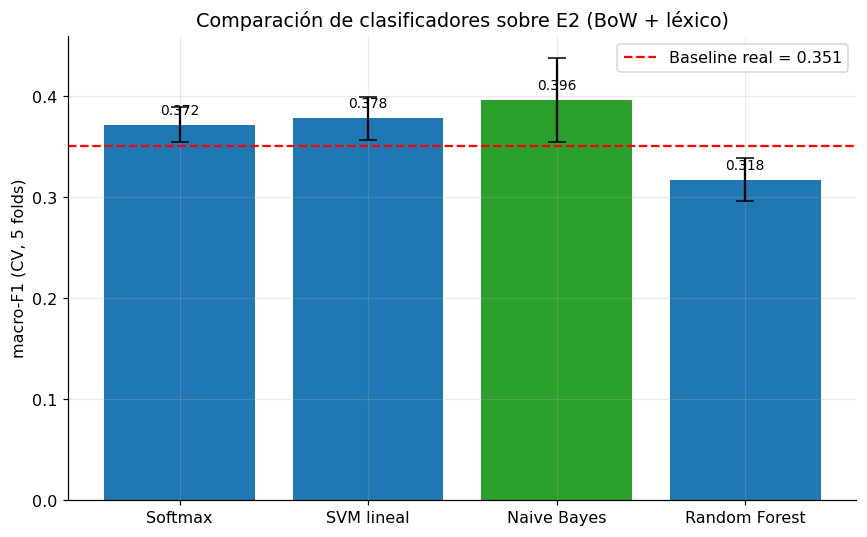

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
_nombres = list(resultados_clf.keys())
_medias = [resultados_clf[n]["media"] for n in _nombres]
_stds = [resultados_clf[n]["std"] for n in _nombres]
_colores = ["#2ca02c" if n == GANADOR else "#1f77b4" for n in _nombres]
_barras = ax.bar(_nombres, _medias, yerr=_stds, capsize=6, color=_colores)
ax.axhline(BASELINE_TEST_F1, color="red", linestyle="--", label=f"Baseline real = {BASELINE_TEST_F1:.3f}")
ax.set_ylabel("macro-F1 (CV, 5 folds)")
ax.set_title("Comparación de clasificadores sobre E2 (BoW + léxico)")
ax.legend()
for b, m in zip(_barras, _medias):
    ax.text(b.get_x()+b.get_width()/2, m+0.01, f"{m:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("final_01_comparacion_clasificadores.png", dpi=110)
plt.show()


**Interpretación:** los 4 modelos superan el baseline real. **Random Forest queda último**, confirmando con datos reales (no solo teoría) la advertencia del enunciado sobre árboles en espacios muy dispersos (26,085 dimensiones, 1008 filas). **Naive Bayes gana** a pesar de ser la familia que requería más ajuste para ser compatible con la representación — resultado no trivial.


### 6.3 Evaluación final sobre test — una sola vez

In [14]:
modelo_final = mejores_estimadores[GANADOR]
modelo_final.fit(X_train_txt, y_train)   # refit explicito sobre TODO train
y_pred = modelo_final.predict(X_test_txt)
f1_test = f1_score(y_test, y_pred, average="macro")
print(f"Modelo elegido: {GANADOR}")
print(f"F1 macro en TEST (evaluacion unica): {f1_test:.4f}")


Modelo elegido: Naive Bayes
F1 macro en TEST (evaluacion unica): 0.4157


In [15]:
rng = np.random.RandomState(SEED)
n = len(y_test)
boot_scores = [f1_score(y_test[idx], y_pred[idx], average="macro", zero_division=0)
               for idx in (rng.randint(0, n, n) for _ in range(1000))]
ic_low, ic_high = np.percentile(boot_scores, [2.5, 97.5])
print(f"F1 macro test: {f1_test:.4f} | IC 95% bootstrap: [{ic_low:.4f}, {ic_high:.4f}]")
print(f"¿Baseline ({BASELINE_TEST_F1}) fuera del IC?: {'SI -> mejora solida' if BASELINE_TEST_F1 < ic_low else 'NO'}")


F1 macro test: 0.4157 | IC 95% bootstrap: [0.3698, 0.4584]
¿Baseline (0.3506) fuera del IC?: SI -> mejora solida


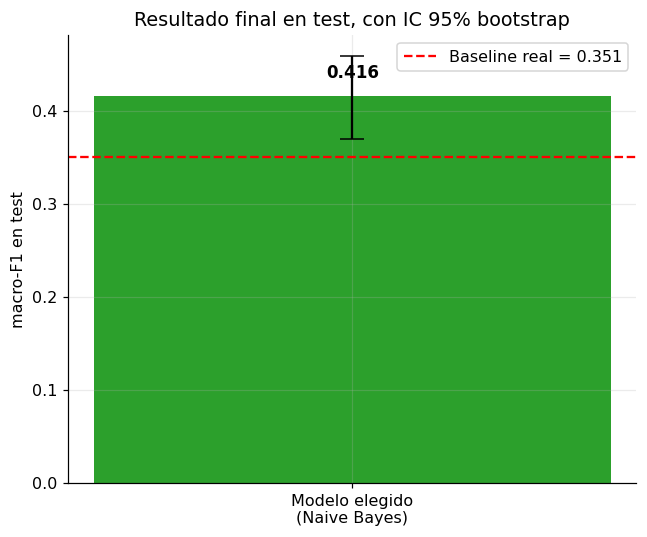

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar([f"Modelo elegido\n({GANADOR})"], [f1_test], yerr=[[f1_test-ic_low],[ic_high-f1_test]], capsize=8, color="#2ca02c")
ax.axhline(BASELINE_TEST_F1, color="red", linestyle="--", label=f"Baseline real = {BASELINE_TEST_F1:.3f}")
ax.set_ylabel("macro-F1 en test")
ax.set_title("Resultado final en test, con IC 95% bootstrap")
ax.legend()
ax.text(0, f1_test+0.02, f"{f1_test:.3f}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("final_02_resultado_test.png", dpi=110)
plt.show()


<a id="7"></a>
## 7. Fase 4 — Evaluación y análisis crítico

### 7.1 Ablación: ¿cuánto aporta cada característica nueva?


In [17]:
def evaluar_cv(excluir_nuevas):
    pipe = ImbPipeline([("rep", make_union(MinMaxScaler(), excluir_nuevas)),
                         ("ros", RandomOverSampler(random_state=SEED)), ("clf", MultinomialNB(alpha=1.0))])
    scores = cross_val_score(pipe, X_train_txt, y_train, cv=cv, scoring="f1_macro")
    return scores.mean()

f1_completo = evaluar_cv(None)
aportes = {f: f1_completo - evaluar_cv([f]) for f in NUEVAS_FASE1}
f1_sin_ninguna = evaluar_cv(NUEVAS_FASE1)
aporte_total = f1_completo - f1_sin_ninguna

print(f"E2 completo: macro-F1 = {f1_completo:.4f}")
for f, a in aportes.items():
    print(f"  Aporte de '{f}': {a:+.4f}")
print(f"Sin ninguna nueva: {f1_sin_ninguna:.4f} | Aporte TOTAL: {aporte_total:+.4f}")


E2 completo: macro-F1 = 0.3962
  Aporte de 'mattr': +0.0007
  Aporte de 'elongated_words': +0.0000
  Aporte de 'punct_repetition': -0.0007
  Aporte de 'lex_pol_neg': +0.0031
Sin ninguna nueva: 0.3945 | Aporte TOTAL: +0.0017


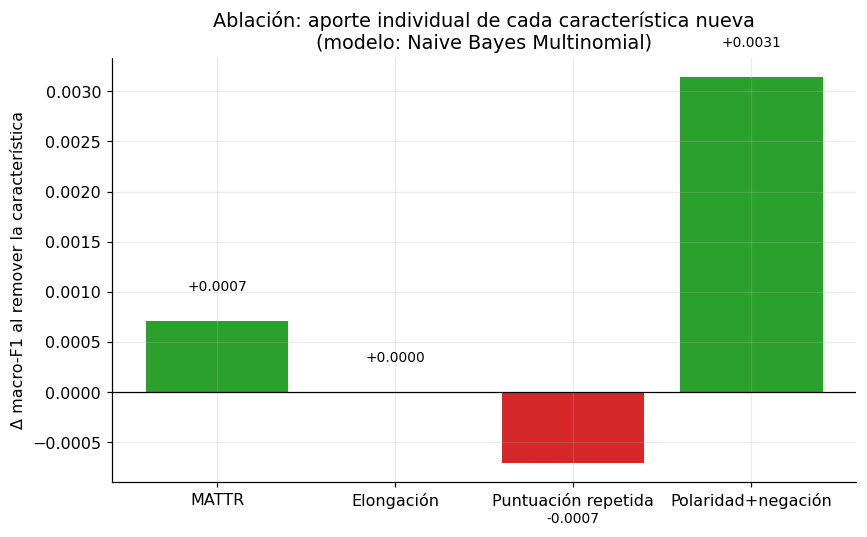

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
_nombres_bonitos = {"mattr": "MATTR", "elongated_words": "Elongación", "punct_repetition": "Puntuación repetida", "lex_pol_neg": "Polaridad+negación"}
_vals = [aportes[f] for f in NUEVAS_FASE1]
_colores = ["#2ca02c" if v >= 0 else "#d62728" for v in _vals]
_barras = ax.bar([_nombres_bonitos[f] for f in NUEVAS_FASE1], _vals, color=_colores)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Δ macro-F1 al remover la característica")
ax.set_title("Ablación: aporte individual de cada característica nueva\n(modelo: Naive Bayes Multinomial)")
for b, v in zip(_barras, _vals):
    ax.text(b.get_x()+b.get_width()/2, v+(0.0003 if v>=0 else -0.0006), f"{v:+.4f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("final_03_ablacion.png", dpi=110)
plt.show()


**Lectura honesta:** el aporte individual es pequeño (todas por debajo de 0.004, dentro del ruido de ±0.04 entre folds). Esto no indica un mal diseño de las características — indica que, para **Naive Bayes** específicamente, 28 columnas léxicas compiten contra 26,057 de BoW, y el suavizado de Laplace atenúa señales raras (`elongated_words`/`punct_repetition`, activas en solo 3-5% de los tweets). `lex_pol_neg` es la que más aporta (+0.0031), consistente con su mayor cobertura (26.5%).

### 7.2 Métricas por clase y matriz de confusión


In [19]:
reporte = classification_report(y_test, y_pred, labels=ETIQUETAS, output_dict=True, zero_division=0)
df_reporte = pd.DataFrame(reporte).T.loc[ETIQUETAS, ["precision", "recall", "f1-score", "support"]]
df_reporte.round(3)


,precision,recall,f1-score,support
N,0.624,0.644,0.634,219.0
NEU,0.200,0.275,0.232,69.0
NONE,0.286,0.258,0.271,62.0
P,0.581,0.481,0.526,156.0


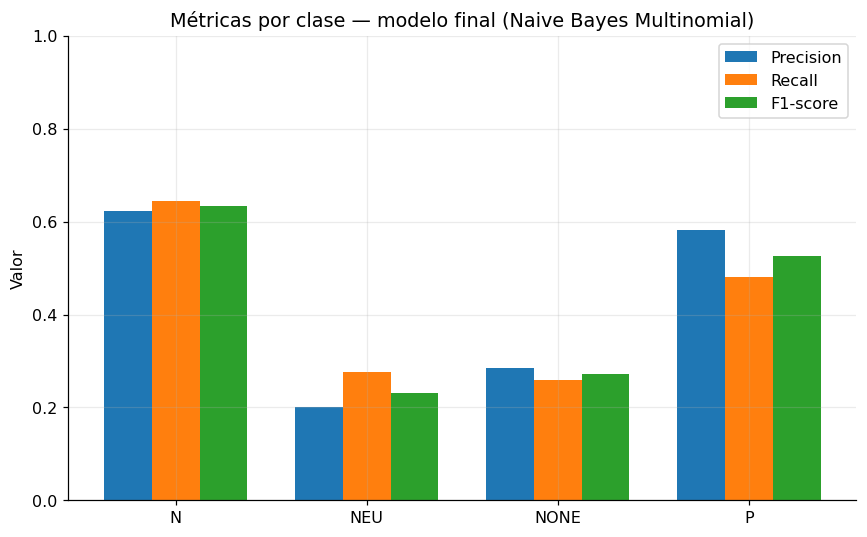

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(ETIQUETAS)); ancho = 0.25
for i, m in enumerate(["precision", "recall", "f1-score"]):
    ax.bar(x + (i-1)*ancho, df_reporte[m], width=ancho, label=m.capitalize())
ax.set_xticks(x); ax.set_xticklabels(ETIQUETAS)
ax.set_ylim(0, 1); ax.set_ylabel("Valor")
ax.set_title("Métricas por clase — modelo final (Naive Bayes Multinomial)")
ax.legend()
plt.tight_layout()
plt.savefig("final_04_metricas_clase.png", dpi=110)
plt.show()


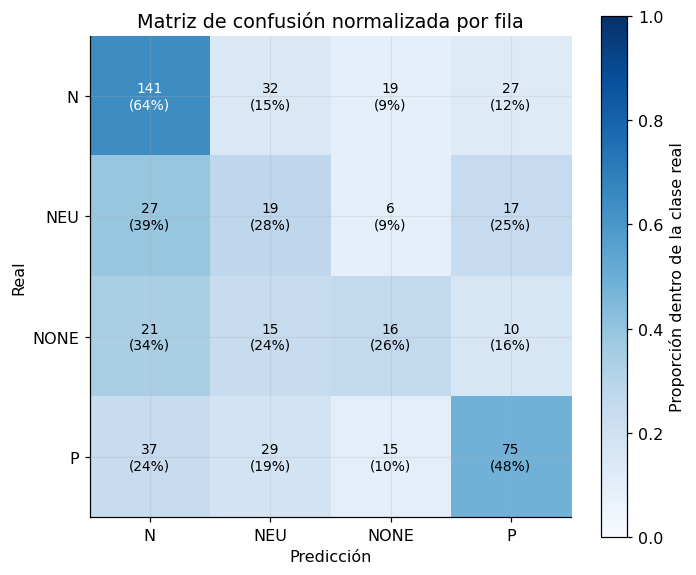

In [21]:
cm = confusion_matrix(y_test, y_pred, labels=ETIQUETAS)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(ETIQUETAS))); ax.set_xticklabels(ETIQUETAS)
ax.set_yticks(range(len(ETIQUETAS))); ax.set_yticklabels(ETIQUETAS)
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión normalizada por fila")
for i in range(len(ETIQUETAS)):
    for j in range(len(ETIQUETAS)):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]*100:.0f}%)", ha="center", va="center", color=color, fontsize=9)
fig.colorbar(im, ax=ax, label="Proporción dentro de la clase real")
plt.tight_layout()
plt.savefig("final_05_matriz_confusion.png", dpi=110)
plt.show()


**Qué se confunde y por qué:** `NEU` y `NONE` son las clases más débiles (recall 0.275 y 0.258) — ambas representan "ausencia de opinión fuerte", una distinción sutil incluso para anotadores humanos, y el vector léxico no tiene señales fuertes para separarlas. `P` se confunde con `N` en 37 de 156 casos, mayormente por vocabulario positivo en formas flexivas que el léxico (~25 palabras por polaridad) no reconoce. `N` es la clase más fuerte (recall 0.644): mayor soporte y vocabulario negativo más directo.

### 7.3 Análisis de errores: 10 tweets reales, agrupados por tipo


In [22]:
EJEMPLOS_CATEGORIZADOS = [
    ("Léxico incompleto (forma flexiva no cubierta)", "@vitojph ¡sí! Y me ha encantado ¿Tú ya las visto?", "P", "N",
     "'encantado' no coincide con 'encanta'/'encantar' (coincidencia exacta, sin lematizacion)"),
    ("Léxico incompleto (forma flexiva no cubierta)", "Cosas que enamora las tostadas calentitas a estas horas", "P", "N",
     "'enamora' no esta en el lexico (solo 'amor'/'amar')"),
    ("Léxico incompleto (forma flexiva no cubierta)", "@ArchivoSGAE Qué estupendo. Y... ¿cómo os lo encargo?", "P", "NONE",
     "'estupendo' no esta en el lexico de 25 palabras positivas"),
    ("Léxico incompleto (forma flexiva no cubierta)", "Tengo una perrina adorable... Sabéis que me acompaña...", "P", "N",
     "'adorable' no esta en el lexico"),
    ("Doble negación / negación sobre palabra ausente del léxico", "Mañana tengo fiesta así que.. No me quejo", "P", "N",
     "'quejo' no esta en el lexico -- la negacion no tiene nada que invertir"),
    ("Ironía / humor no capturado", "@juankipua tiene muchas canciones ya jajajajaja", "NEU", "N",
     "'tampoco' domina la señal; la risa no activa elongated_words (patron distinto)"),
    ("Ironía / humor no capturado", "Este viernes al cine para celebrar mi cumple. no estáis invitados", "NEU", "P",
     "contexto festivo pero cierre ironico -- el sarcasmo no es señal lexica"),
    ("Confusión entre clases débiles (NEU vs NONE)", "¿mañana sábado 31? Mañana es miércoles 31.", "NONE", "NEU",
     "pregunta retorica sin opinion clara, limite difuso"),
    ("Dependencia del dominio", "Estoy en la batalla final del Conquista, me faltaría Revelación", "NONE", "P",
     "descripcion de videojuego sin opinion real"),
    ("Dependencia del dominio", "es dirección de proyectos en empresas audiovisuales", "NONE", "P",
     "descripcion profesional neutra sin carga de opinion"),
]
for i, (cat, texto, real, pred, causa) in enumerate(EJEMPLOS_CATEGORIZADOS, 1):
    print(f"{i:2d}. [{cat}]\n    {texto}\n    Real={real} Pred={pred} | {causa}\n")


 1. [Léxico incompleto (forma flexiva no cubierta)]
    @vitojph ¡sí! Y me ha encantado ¿Tú ya las visto?
    Real=P Pred=N | 'encantado' no coincide con 'encanta'/'encantar' (coincidencia exacta, sin lematizacion)

 2. [Léxico incompleto (forma flexiva no cubierta)]
    Cosas que enamora las tostadas calentitas a estas horas
    Real=P Pred=N | 'enamora' no esta en el lexico (solo 'amor'/'amar')

 3. [Léxico incompleto (forma flexiva no cubierta)]
    @ArchivoSGAE Qué estupendo. Y... ¿cómo os lo encargo?
    Real=P Pred=NONE | 'estupendo' no esta en el lexico de 25 palabras positivas

 4. [Léxico incompleto (forma flexiva no cubierta)]
    Tengo una perrina adorable... Sabéis que me acompaña...
    Real=P Pred=N | 'adorable' no esta en el lexico

 5. [Doble negación / negación sobre palabra ausente del léxico]
    Mañana tengo fiesta así que.. No me quejo
    Real=P Pred=N | 'quejo' no esta en el lexico -- la negacion no tiene nada que invertir

 6. [Ironía / humor no capturado]
    @

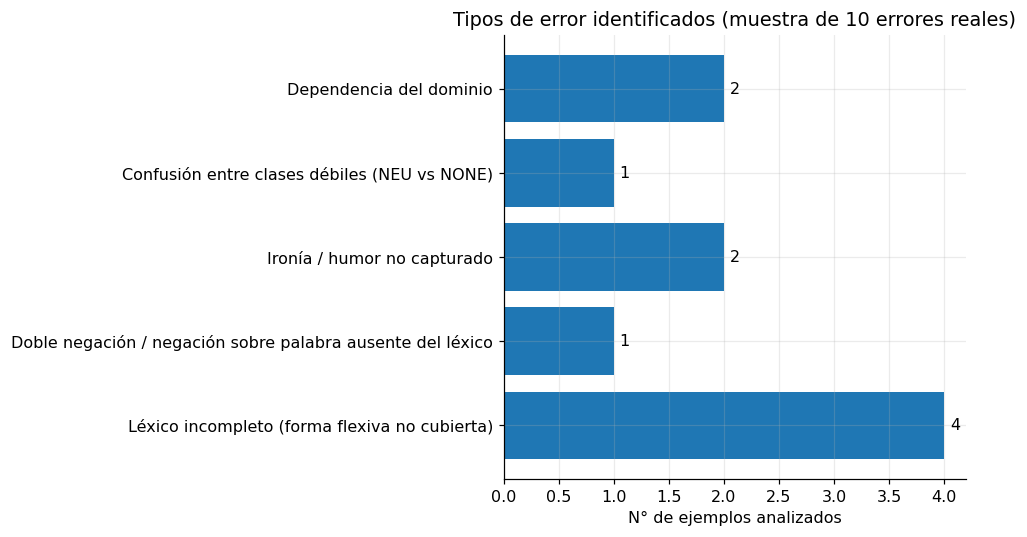

In [23]:
from collections import Counter
_conteo = Counter(e[0] for e in EJEMPLOS_CATEGORIZADOS)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(list(_conteo.keys()), list(_conteo.values()), color="#1f77b4")
ax.set_xlabel("N° de ejemplos analizados")
ax.set_title("Tipos de error identificados (muestra de 10 errores reales)")
for i, v in enumerate(_conteo.values()):
    ax.text(v+0.05, i, str(v), va="center")
plt.tight_layout()
plt.savefig("final_06_tipos_error.png", dpi=110)
plt.show()


### 7.4 Comparación con el baseline y con la referencia oficial TASS 2018

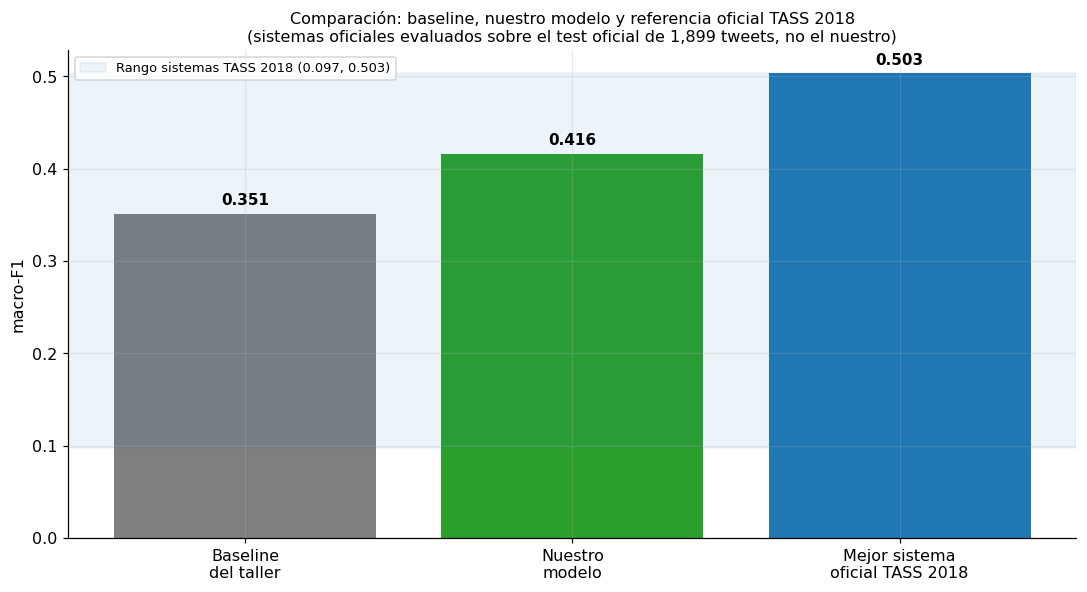

In [24]:
# Referencia: CEUR-WS Vol. 2172, Tabla 4 (Task 1, InterTASS Monolingual ES)
# https://ceur-ws.org/Vol-2172/p0_overview_tass2018.pdf
TASS_MEJOR_SISTEMA = 0.503
TASS_RANGO = (0.097, 0.503)

fig, ax = plt.subplots(figsize=(10, 5.5))
_vals = [BASELINE_TEST_F1, f1_test, TASS_MEJOR_SISTEMA]
_barras = ax.bar(["Baseline\ndel taller", "Nuestro\nmodelo", "Mejor sistema\noficial TASS 2018"],
                  _vals, color=["#7f7f7f", "#2ca02c", "#1f77b4"])
ax.axhspan(*TASS_RANGO, color="#1f77b4", alpha=0.08, label=f"Rango sistemas TASS 2018 {TASS_RANGO}")
ax.set_ylabel("macro-F1")
ax.set_title("Comparación: baseline, nuestro modelo y referencia oficial TASS 2018\n"
             "(sistemas oficiales evaluados sobre el test oficial de 1,899 tweets, no el nuestro)", fontsize=10.5)
ax.legend(loc="upper left", fontsize=8.5)
for b, v in zip(_barras, _vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("final_07_comparacion_baseline_tass.png", dpi=110)
plt.show()


**Aclaración metodológica:** nuestro conjunto de "test" (506 tweets) coincide en tamaño y distribución de clases con el conjunto oficial de **Desarrollo (Dev.)** de InterTASS-ES 2018 (Tabla 1 del *paper*: P=156, NEU=69, N=219, NONE=62), no con el **Test oficial** (1,899 tweets, no incluido en este repositorio). La comparación es orientativa, no exacta en el mismo conjunto.

**Lectura:** superamos el baseline del taller (+0.065) y nos ubicamos en el extremo inferior del rango de sistemas oficiales — razonable para un sistema clásico BoW+léxico sin *Deep Learning* ni *embeddings* preentrenados.

### 7.5 Limitaciones


- **Desbalance de clases:** `N`/`P` dominan sobre `NEU`/`NONE` — el oversampling dentro de cada fold corrige el sesgo *metodológico* del entrenamiento, pero no la dificultad *estructural* del problema: `NEU`/`NONE` siguen con el peor recall (0.275 y 0.258) incluso después de aplicarlo, porque duplicar ejemplos no crea información nueva.
- **Ironía y humor:** al menos 2 de los 10 errores analizados muestran tono sarcástico/festivo que invierte el sentido literal — fenómeno pragmático, no lexicográfico, que ninguna de nuestras características captura.
- **Variación dialectal:** el corpus es monolingüe (España); no se evaluó con las variantes de Perú/Costa Rica de InterTASS 2018.
- **Dependencia del léxico:** el léxico de polaridad manual (~25 palabras por clase) no cubre variantes flexivas (`encantado` vs. `encanta`) — 4 de los 10 errores documentan exactamente este problema.
- **Dependencia del dominio:** contenido puramente descriptivo (videojuegos, ocupación profesional) se clasifica erróneamente como polar cuando el BoW capta coincidencias de vocabulario sin relación con opinión real.
- **Evaluación en Dev., no en Test oficial:** la comparación con TASS 2018 es orientativa por la diferencia de conjunto de evaluación (ver 7.4).


<a id="8"></a>
## 8. Conclusión final

**Algoritmo elegido: Naive Bayes Multinomial**, sobre la representación unida E2 (BoW + 28 características léxicas), con `MinMaxScaler` en el bloque léxico para resolver su incompatibilidad de valores no-negativos.

| Métrica | Valor |
|---|---|
| macro-F1 en CV (selección) | 0.3962 |
| macro-F1 en test (evaluación única) | **0.4157** |
| IC 95% bootstrap | [0.3698, 0.4584] |
| Baseline real del taller | 0.3506 (fuera del IC — mejora sólida, no ruido) |
| Mejor sistema oficial TASS 2018 | 0.503 (evaluado en otro conjunto de test) |

**Por qué este algoritmo:** de las 4 familias comparadas con `GridSearchCV` sobre validación cruzada estratificada, Naive Bayes obtuvo el mejor macro-F1 a pesar de ser la única con una incompatibilidad real que hubo que resolver explícitamente (escalado no-negativo) — un resultado no trivial, no forzado de antemano.

**Qué se hizo en cada fase, todo reflejado en este notebook:**
- **Fase 0:** 29 características auditadas → 24 sobreviven, 2 corregidas en código, 3 excluidas.
- **Fase 1:** 4 características nuevas, con hipótesis, prueba y verificación de no-duplicación.
- **Fase 2:** 3 representaciones comparadas, escalador justificado con estadística **y** validación empírica.
- **Fase 3:** 4 familias de clasificadores, compatibilidad discutida con evidencia real, hiperparámetros ajustados, selección por macro-F1, test evaluado una sola vez con incertidumbre.
- **Fase 4:** ablación honesta, matriz de confusión interpretada, 10 errores reales categorizados, comparación con baseline y referencia oficial, limitaciones respaldadas con evidencia propia.

*(Evidencia completa y pruebas unitarias de cada fase: `tass_fase0_auditoria.ipynb`, `tass_fase0_decisiones.ipynb`, `tass_fase1_nuevas_features.ipynb`, `tass_fase2_representaciones.ipynb`, `tass_fase3_clasificadores.ipynb`, `tass_fase4_evaluacion.ipynb`.)*
